# Australian Weather Data: Preprocessing and Feature Extraction

This notebook performs data cleaning, handles missing values, and extracts relevant features for machine learning using the `weatherAUS.csv` dataset.

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/weatherAUS.csv')

# Display basic info and first few rows
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### 1. Feature Extraction from Date

We will convert the `Date` column to datetime objects and extract Year, Month, and Day to capture seasonal patterns.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Drop original Date column
df.drop('Date', axis=1, inplace=True)
display(df[['Year', 'Month', 'Day']].head())

,Year,Month,Day
0,2008,12,1
1,2008,12,2
2,2008,12,3
3,2008,12,4
4,2008,12,5


### 2. Handling Missing Values

We will impute numerical columns with the median and categorical columns with the mode.

In [ ]:
# Numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


### 3. Feature Encoding

We'll use Label Encoding for binary features (RainToday, RainTomorrow) and One-Hot Encoding for multi-class categorical features like 'Location' and 'WindDir'.

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Binary encoding for target and binary features
le = LabelEncoder()
df['RainToday'] = le.fit_transform(df['RainToday'])
df['RainTomorrow'] = le.fit_transform(df['RainTomorrow'])

# One-Hot Encoding for other categories
# This automatically handles the conversion and expansion of features
cat_to_encode = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
df = pd.get_dummies(df, columns=cat_to_encode, drop_first=True)

print("Final shape of the preprocessed dataset:", df.shape)
display(df.head())

Final shape of the preprocessed dataset: (145460, 114)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.8,8.4,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.8,8.4,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.8,8.4,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.8,8.4,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,17.5,32.3,1.0,4.8,8.4,41.0,7.0,20.0,82.0,33.0,...,False,True,False,False,False,False,False,False,False,False


### 4. Data Splitting and Scaling

Before training the ANN, we need to split the data into features (X) and target (y), and then normalize the data to help the neural network converge faster.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")

Training set shape: (116368, 113)


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Note: SMOTE should only be applied to the training data to avoid data leakage
print(f"Class distribution before SMOTE: {Counter(y_train)}")

smt = SMOTE(random_state=42)
X_train_bal, y_train_bal = smt.fit_resample(X_train, y_train)

print(f"Class distribution after SMOTE: {Counter(y_train_bal)}")

Class distribution before SMOTE: Counter({0: 90911, 1: 25457})
Class distribution after SMOTE: Counter({1: 90911, 0: 90911})


### 5. Building and Training the ANN

We will use a multi-layer perceptron with Adam optimizer and binary crossentropy loss.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features and target
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model adjusted for the new input shape
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3637/3637 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8370 - loss: 0.3754 - val_accuracy: 0.8511 - val_loss: 0.3422
Epoch 2/50
3637/3637 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8526 - loss: 0.3442 - val_accuracy: 0.8544 - val_loss: 0.3372
Epoch 3/50
3637/3637 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8568 - loss: 0.3352 - val_accuracy: 0.8559 - val_loss: 0.3347
Epoch 4/50
3637/3637 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8593 - loss: 0.3307 - val_accuracy: 0.8574 - val_loss: 0.3313
Epoch 5/50
3637/3637 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8601 - loss: 0.3267 - val_accuracy: 0.8583 - val_loss: 0.3285
Epoch 6/50
3637/3637 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8615 - loss: 0.3245 - val_accuracy: 0.8581 - val_loss: 0.3267
Epoch 7/50
3637/3637 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8624 - loss: 0.3225 - val_accuracy: 0.8586 - val_loss: 0.3253
Epoch 8/50
3637/3637 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8632 - loss: 0.3206 - val_accura

### 6. Evaluating the Model Loss

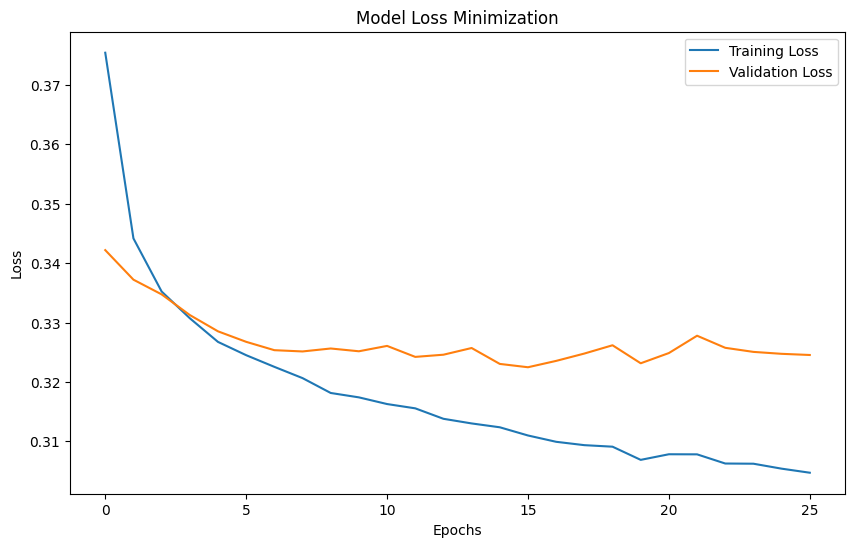

910/910 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8615 - loss: 0.3225
Final Test Loss: 0.3225
Final Test Accuracy: 0.8615


In [ ]:
import matplotlib.pyplot as plt

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Minimization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Final Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Final Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")